## ETL

In [1]:
# Celda 1: Configuración general

from pathlib import Path
import sys
import os
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Detectar la raíz del proyecto.
# Funciona si el notebook se abre desde notebooks/ o desde la raíz.
RUTA_ACTUAL = Path.cwd()
PROJECT_ROOT = RUTA_ACTUAL.parent if RUTA_ACTUAL.name == "notebooks" else RUTA_ACTUAL

os.chdir(PROJECT_ROOT)

SRC_PATH = str(PROJECT_ROOT / "src")
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from extract import descargar_dataset, extraer_datos
from transform import (
    preparar_metadata,
    crear_muestra_balanceada,
    obtener_una_imagen_por_forma,
    procesar_multiples_resoluciones,
    guardar_metadata_muestra
)

print(f"Raíz del proyecto: {PROJECT_ROOT}")


Raíz del proyecto: /data/ulead-36/Proyecto


In [3]:
# Celda 2: Parámetros de ejecución

# True: procesa una muestra pequeña para pruebas.
# False: procesa todo el dataset.
MODO_PRUEBA = False

# Cambiar a True solamente si el dataset todavía no existe en data/raw.
DESCARGAR_DATASET = False

# Parámetros de prueba
MUESTRAS_POR_FORMA = 5
LIMITE_MUESTRA = 100
NUM_PROCESOS_PRUEBA = 2
TAMANO_LOTE_PRUEBA = 50

# Parámetros para el dataset completo
NUM_PROCESOS_COMPLETO = 8
TAMANO_LOTE_COMPLETO = 2000

# Resoluciones requeridas
RESOLUCIONES = [
    #(224, 224),
    (256, 256)
]

CARPETA_SALIDA_PRUEBA = "data/processed_sample"
CARPETA_SALIDA_COMPLETA = "data/processed"

print("Modo seleccionado:", "PRUEBA" if MODO_PRUEBA else "DATASET COMPLETO")


Modo seleccionado: DATASET COMPLETO


In [4]:
# Celda 3: Descargar el dataset de Kaggle (opcional)

if DESCARGAR_DATASET:
    print("Descargando dataset...")
    descargar_dataset(
        ruta_destino="data/raw"
    )
else:
    print("Descarga omitida. Se utilizará el dataset existente en data/raw.")


Descarga omitida. Se utilizará el dataset existente en data/raw.


In [5]:
# Celda 4: Extraer rutas, etiquetas y metadatos

rutas, labels, metadata = extraer_datos(
    carpeta_padre="data/raw"
)

print(f"Total de imágenes encontradas: {len(rutas)}")
print(f"Total de etiquetas: {len(labels)}")
print(f"Total de registros en el CSV: {len(metadata)}")

display(metadata.head())



Iniciando etapa de extracción...
Se encontraron 44831 imágenes.
Metadata cargada correctamente: 48765 registros.
Columnas encontradas: ['path_to_img', 'stock_number', 'shape', 'carat', 'clarity', 'colour', 'cut', 'polish', 'symmetry', 'fluorescence', 'lab', 'length', 'width', 'depth']
Etapa de extracción finalizada correctamente.

Total de imágenes encontradas: 44831
Total de etiquetas: 44831
Total de registros en el CSV: 48765


,path_to_img,stock_number,shape,carat,clarity,colour,cut,polish,symmetry,fluorescence,lab,length,width,depth
0,web_scraped/cushion/2106452.jpg,2106452,cushion,0.55,SI2,N,VG,EX,VG,N,GIA,4.56,4.44,3.09
1,web_scraped/cushion/2042329.jpg,2042329,cushion,0.52,SI2,Y-Z,EX,EX,VG,F,GIA,4.40,4.31,2.99
2,web_scraped/cushion/2055268.jpg,2055268,cushion,0.50,SI1,L,VG,EX,VG,N,GIA,4.87,4.19,2.89
3,web_scraped/cushion/2128779.jpg,2128779,cushion,0.50,VS2,M,EX,EX,VG,F,GIA,4.73,4.28,2.84
4,web_scraped/cushion/2103991.jpg,2103991,cushion,0.51,SI1,M,EX,EX,VG,N,GIA,4.47,4.44,3.05


In [6]:
# Celda 5: Analizar la distribución original

print("Distribución original por forma:")
display(
    metadata["shape"]
    .value_counts(dropna=False)
    .rename_axis("shape")
    .reset_index(name="cantidad")
)

print("Distribución original por color:")
display(
    metadata["colour"]
    .value_counts(dropna=False)
    .rename_axis("colour")
    .reset_index(name="cantidad")
)

print("Distribución original por claridad:")
display(
    metadata["clarity"]
    .value_counts(dropna=False)
    .rename_axis("clarity")
    .reset_index(name="cantidad")
)


Distribución original por forma:


,shape,cantidad
0,round,21032
1,oval,6492
2,cushion,5341
3,pear,4338
4,princess,3949
5,heart,3756
6,emerald,3392
7,marquise,465


Distribución original por color:


,colour,cantidad
0,G,7674
1,F,6957
2,H,6555
3,E,6239
4,D,5824
5,I,5304
6,J,4273
7,K,2628
8,L,1388
9,M,754


Distribución original por claridad:


,clarity,cantidad
0,VS2,10688
1,SI1,10244
2,SI2,10019
3,VS1,9080
4,VVS2,4716
5,VVS1,2753
6,IF,854
7,I1,280
8,NaN,38
9,I2,35


In [9]:
# Celda 6: Preparar y validar los metadatos

datos_validos = preparar_metadata(
    metadata=metadata,
    carpeta_datos="data/raw"
)

print(f"Registros válidos para procesar: {len(datos_validos)}")

display(
    datos_validos[
        [
            "path_to_img",
            "shape",
            "colour",
            "clarity",
            "full_path"
        ]
    ].head()
)


Registros iniciales: 48765
Registros válidos: 44504
Registros descartados: 4261
Registros válidos para procesar: 44504


,path_to_img,shape,colour,clarity,full_path
0,web_scraped/cushion/2106452.jpg,cushion,N,SI2,data/raw/web_scraped/cushion/2106452.jpg
1,web_scraped/cushion/2042329.jpg,cushion,Y-Z,SI2,data/raw/web_scraped/cushion/2042329.jpg
2,web_scraped/cushion/2055268.jpg,cushion,L,SI1,data/raw/web_scraped/cushion/2055268.jpg
3,web_scraped/cushion/2128779.jpg,cushion,M,VS2,data/raw/web_scraped/cushion/2128779.jpg
4,web_scraped/cushion/2103991.jpg,cushion,M,SI1,data/raw/web_scraped/cushion/2103991.jpg


In [10]:
# Celda 7: Seleccionar muestra o dataset completo

if MODO_PRUEBA:
    datos_a_procesar = crear_muestra_balanceada(
        metadata=datos_validos,
        muestras_por_forma=MUESTRAS_POR_FORMA,
        limite_total=LIMITE_MUESTRA,
        semilla=42
    )

    carpeta_salida = CARPETA_SALIDA_PRUEBA
    num_procesos = NUM_PROCESOS_PRUEBA
    tamano_lote = TAMANO_LOTE_PRUEBA

else:
    datos_a_procesar = datos_validos.copy()

    carpeta_salida = CARPETA_SALIDA_COMPLETA
    num_procesos = NUM_PROCESOS_COMPLETO
    tamano_lote = TAMANO_LOTE_COMPLETO

print(f"Imágenes a procesar: {len(datos_a_procesar)}")
print(f"Carpeta de salida: {carpeta_salida}")
print(f"Número de procesos: {num_procesos}")
print(f"Tamaño de lote: {tamano_lote}")


Imágenes a procesar: 44504
Carpeta de salida: data/processed
Número de procesos: 8
Tamaño de lote: 2000


In [17]:
# Celda 8: Revisar distribuciones de los datos seleccionados

def tabla_distribucion(serie, nombre_columna):
    """
    Construye una tabla de frecuencias con Cantidad y % (ordenada por índice).
    """
    cantidad = serie.value_counts().sort_index()
    porcentaje = (cantidad / cantidad.sum() * 100).round(2)

    tabla = pd.DataFrame({
        "Cantidad": cantidad,
        "%": porcentaje
    })
    tabla.index.name = nombre_columna
    return tabla


print("Distribución por forma (shape):")
display(tabla_distribucion(datos_a_procesar["shape"], "shape"))

print("\nDistribución por color (colour):")
display(tabla_distribucion(datos_a_procesar["colour"], "colour"))

print("\nDistribución por claridad (clarity):")
display(tabla_distribucion(datos_a_procesar["clarity"], "clarity"))


print("\nValores faltantes:")
faltantes = datos_a_procesar[["shape", "colour", "clarity"]].isna().sum()
faltantes_pct = (faltantes / len(datos_a_procesar) * 100).round(2)

tabla_faltantes = pd.DataFrame({
    "Cantidad": faltantes,
    "%": faltantes_pct
})
display(tabla_faltantes)

Distribución por forma (shape):


,Cantidad,%
shape,,
cushion,5191,11.66
emerald,3389,7.62
heart,3738,8.40
marquise,459,1.03
oval,6447,14.49
pear,4279,9.61
princess,3943,8.86
round,17058,38.33



Distribución por color (colour):


,Cantidad,%
colour,,
D,5500,12.36
E,5897,13.25
F,6521,14.65
G,7085,15.92
H,6017,13.52
I,4861,10.92
J,3854,8.66
K,2341,5.26
L,1221,2.74



Distribución por claridad (clarity):


,Cantidad,%
clarity,,
FL,22,0.05
I1,213,0.48
IF,766,1.72
SI1,9395,21.11
SI2,8771,19.71
VS1,8398,18.87
VS2,10006,22.48
VVS1,2557,5.75
VVS2,4376,9.83



Valores faltantes:


,Cantidad,%
shape,0,0.0
colour,0,0.0
clarity,0,0.0


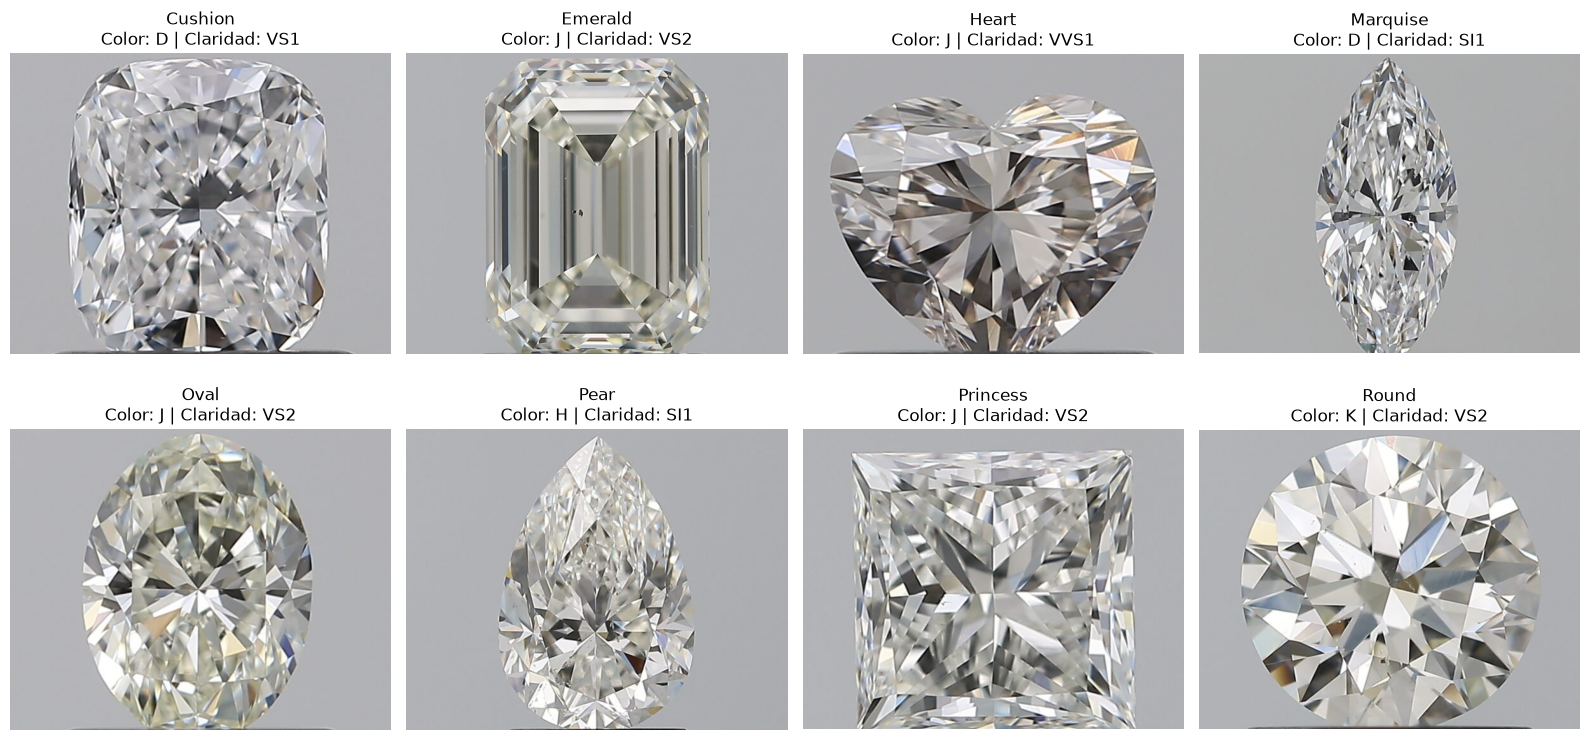

In [18]:
# Celda 9: Visualizar una imagen por cada forma

muestra_visual = obtener_una_imagen_por_forma(
    metadata=datos_validos,
    semilla=42
)

cantidad = len(muestra_visual)
columnas = 4
filas = int(np.ceil(cantidad / columnas))

plt.figure(figsize=(16, filas * 4))

for posicion, (_, registro) in enumerate(
    muestra_visual.iterrows(),
    start=1
):
    imagen = cv2.imread(registro["full_path"])

    plt.subplot(filas, columnas, posicion)

    if imagen is not None:
        imagen = cv2.cvtColor(
            imagen,
            cv2.COLOR_BGR2RGB
        )
        plt.imshow(imagen)

    plt.title(
        f"{registro['shape'].title()}\n"
        f"Color: {registro['colour']} | "
        f"Claridad: {registro['clarity']}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


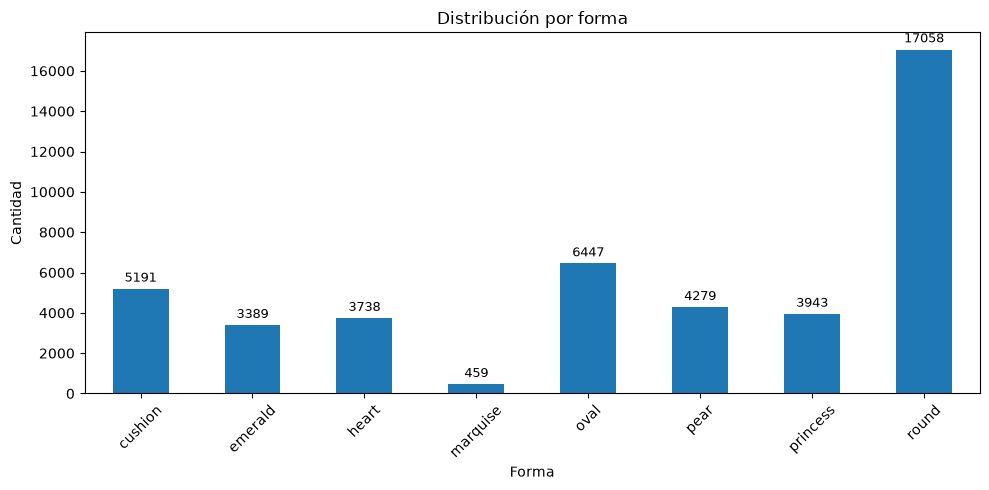

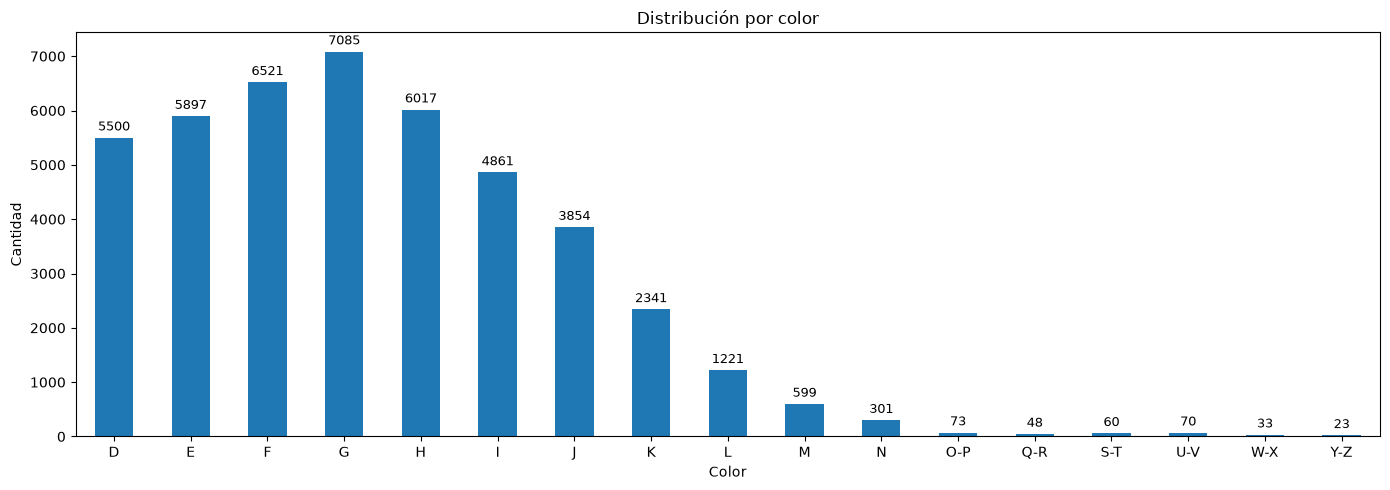

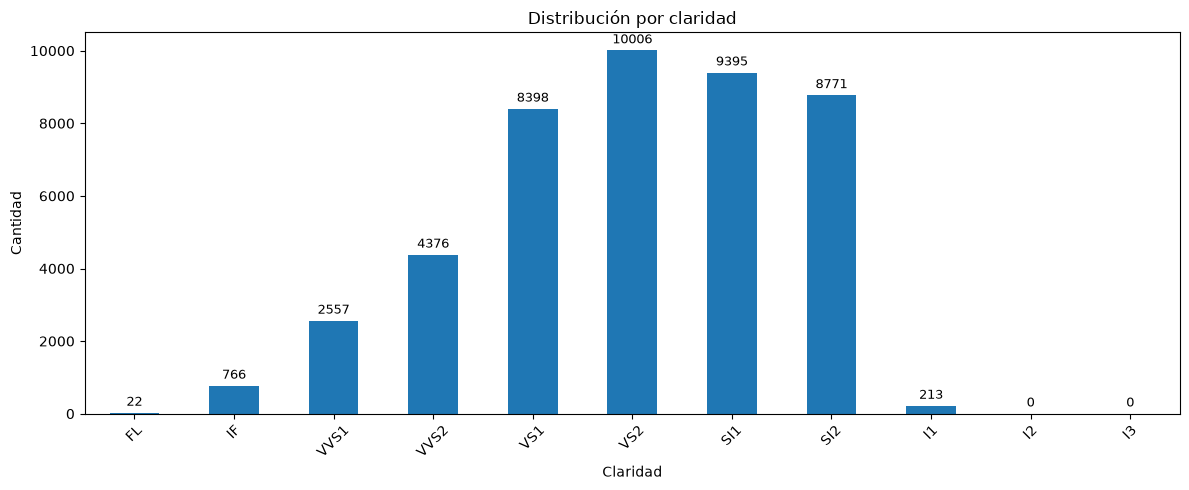

In [20]:
# Celda 10: Analizar la distribución del dataset

# Orden estándar GIA para colores D-N + rangos extendidos que existen en el dataset
orden_colores = list("DEFGHIJKLMN") + ["O-P", "Q-R", "S-T", "U-V", "W-X", "Y-Z"]

# Orden estándar GIA para claridad
orden_claridad = [
    "FL", "IF", "VVS1", "VVS2", "VS1", "VS2",
    "SI1", "SI2", "I1", "I2", "I3"
]

def agregar_etiquetas_barras(ax):
    """
    Agrega la cantidad sobre cada barra del gráfico.
    """
    for barra in ax.patches:
        altura = barra.get_height()
        ax.annotate(
            f"{int(altura)}",
            (barra.get_x() + barra.get_width() / 2, altura),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points"
        )

# --------------------------
# Distribución por forma
# --------------------------
conteo_formas = (
    datos_a_procesar["shape"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
conteo_formas.plot(kind="bar", ax=ax)
ax.set_title("Distribución por forma")
ax.set_xlabel("Forma")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
agregar_etiquetas_barras(ax)
plt.tight_layout()
plt.show()

# --------------------------
# Distribución por color
# --------------------------
conteo_colores = (
    datos_a_procesar["colour"]
    .value_counts()
    .reindex(orden_colores, fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
conteo_colores.plot(kind="bar", ax=ax)
ax.set_title("Distribución por color")
ax.set_xlabel("Color")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=0)
agregar_etiquetas_barras(ax)
plt.tight_layout()
plt.show()

# --------------------------
# Distribución por claridad
# --------------------------
conteo_claridad = (
    datos_a_procesar["clarity"]
    .value_counts()
    .reindex(orden_claridad, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
conteo_claridad.plot(kind="bar", ax=ax)
ax.set_title("Distribución por claridad")
ax.set_xlabel("Claridad")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
agregar_etiquetas_barras(ax)
plt.tight_layout()
plt.show()

In [ ]:
# Celda 11: Filtrar categorías con muy pocas observaciones

# Categorías a eliminar

claridades_eliminar = [
    "FL",
    "I1",
    "I2",
    "I3"
]

colores_eliminar = [
    "O-P",
    "Q-R",
    "S-T",
    "U-V",
    "W-X",
    "Y-Z"
]

# Resumen inicial

registros_iniciales = len(datos_a_procesar)

print("=" * 60)
print("FILTRADO DEL DATASET")
print("=" * 60)

print(f"\nRegistros iniciales: {registros_iniciales:,}")

print("\nClaridades eliminadas:")
for claridad in claridades_eliminar:
    print(f"  • {claridad}")

print("\nColores eliminados:")
for color in colores_eliminar:
    print(f"  • {color}")

# Aplicar filtros

datos_a_procesar = (
    datos_a_procesar[
        (~datos_a_procesar["clarity"].isin(claridades_eliminar)) &
        (~datos_a_procesar["colour"].isin(colores_eliminar))
    ]
    .reset_index(drop=True)
)


registros_finales = len(datos_a_procesar)

print("RESULTADO DEL FILTRADO")

print(f"Registros finales:    {registros_finales:,}")
print(f"Registros eliminados: {registros_iniciales - registros_finales:,}")

print("\nDistribución final por forma:")
display(
    datos_a_procesar["shape"]
    .value_counts()
    .sort_index()
    .to_frame("Cantidad")
)

print("\nDistribución final por color:")
display(
    datos_a_procesar["colour"]
    .value_counts()
    .sort_index()
    .to_frame("Cantidad")
)

print("\nDistribución final por claridad:")
display(
    datos_a_procesar["clarity"]
    .value_counts()
    .sort_index()
    .to_frame("Cantidad")
)

FILTRADO DEL DATASET

Registros iniciales: 43,964

Claridades eliminadas:
  • FL
  • I1
  • I2
  • I3

Colores eliminados:
  • O-P
  • Q-R
  • S-T
  • U-V
  • W-X
  • Y-Z
RESULTADO DEL FILTRADO
Registros finales:    43,964
Registros eliminados: 0

Distribución final por forma:


,Cantidad
shape,
cushion,5110
emerald,3344
heart,3720
marquise,456
oval,6377
pear,4234
princess,3920
round,16803



Distribución final por color:


,Cantidad
colour,
D,5477
E,5873
F,6489
G,7044
H,5982
I,4834
J,3830
K,2325
L,1211



Distribución final por claridad:


,Cantidad
clarity,
IF,758
SI1,9346
SI2,8707
VS1,8345
VS2,9942
VVS1,2536
VVS2,4330


In [ ]:
# Celda 12: Guardar los metadatos de las imágenes seleccionadas

ruta_metadata_salida = os.path.join(
    carpeta_salida,
    "metadata_procesada.csv"
)

guardar_metadata_muestra(
    metadata=datos_a_procesar,
    ruta_salida=ruta_metadata_salida
)


Metadatos guardados en: data/processed/metadata_procesada.csv


In [ ]:
# Celda 13: Procesar las imágenes en 256 × 256

rutas_a_procesar = datos_a_procesar["full_path"].tolist()

print("=" * 60)
print("PROCESAMIENTO DE IMÁGENES")
print("=" * 60)
print(f"Total de imágenes a procesar: {len(rutas_a_procesar):,}")
print(f"Resoluciones: {RESOLUCIONES}")
print(f"Número de procesos: {num_procesos}")
print(f"Tamaño del lote: {tamano_lote:,}")

inicio = time.time()

resultados = procesar_multiples_resoluciones(
    rutas_imagenes=rutas_a_procesar,
    resoluciones=RESOLUCIONES,
    num_procesos=num_procesos,
    tamaño_lote=tamano_lote,
    carpeta_salida=carpeta_salida
)

tiempo_total = time.time() - inicio

print("\n" + "=" * 60)
print("PROCESAMIENTO FINALIZADO")
print("=" * 60)
print(f"Imágenes procesadas: {len(rutas_a_procesar):,}")
print(f"Tiempo total: {tiempo_total / 60:.2f} minutos")


VALIDACIÓN DEL ETL

Resolución 256x256


Imágenes válidas: 43,962

Total de rutas únicas: 43,962
Metadata original:     43,964
Metadata sincronizada: 43,962
Registros eliminados:  2

Metadata actualizada:
data/processed/metadata_procesada.csv

ETL VALIDADO CORRECTAMENTE
Imágenes finales: 43,962


In [27]:
# Celda 14: Validar y sincronizar metadata con los archivos NPZ

from pathlib import Path
import numpy as np
import pandas as pd

print("=" * 60)
print("VALIDACIÓN DEL ETL")
print("=" * 60)

# ==========================================
# Leer todas las rutas almacenadas en los NPZ
# ==========================================

rutas_npz = []

for resolucion in RESOLUCIONES:

    carpeta_npz = (
        Path(carpeta_salida)
        / f"{resolucion[0]}x{resolucion[1]}"
    )

    archivos = sorted(carpeta_npz.glob("*.npz"))

    print(f"\nResolución {resolucion[0]}x{resolucion[1]}")

    total = 0

    for archivo in archivos:

        datos = np.load(archivo, allow_pickle=True)

        rutas = datos["paths"].tolist()

        rutas_npz.extend(rutas)

        total += len(rutas)

    print(f"Imágenes válidas: {total:,}")

# ==========================================
# Eliminar duplicados
# ==========================================

rutas_npz = sorted(set(rutas_npz))

print(f"\nTotal de rutas únicas: {len(rutas_npz):,}")

# ==========================================
# Sincronizar metadata
# ==========================================

metadata_sincronizada = (
    datos_a_procesar[
        datos_a_procesar["full_path"].isin(rutas_npz)
    ]
    .reset_index(drop=True)
)

print(f"Metadata original:     {len(datos_a_procesar):,}")
print(f"Metadata sincronizada: {len(metadata_sincronizada):,}")
print(
    f"Registros eliminados:  "
    f"{len(datos_a_procesar)-len(metadata_sincronizada):,}"
)

# ==========================================
# Guardar metadata sincronizada
# ==========================================

ruta_metadata = (
    Path(carpeta_salida)
    / "metadata_procesada.csv"
)

metadata_sincronizada.to_csv(
    ruta_metadata,
    index=False
)

print(f"\nMetadata actualizada:")
print(ruta_metadata)

# ==========================================
# Validación final
# ==========================================

assert len(metadata_sincronizada) == len(rutas_npz), (
    "La metadata sigue sin coincidir con los NPZ."
)

print("\nETL VALIDADO CORRECTAMENTE")
print(f"Imágenes finales: {len(metadata_sincronizada):,}")

VALIDACIÓN DEL ETL

Resolución 256x256
Imágenes válidas: 43,962

Total de rutas únicas: 43,962
Metadata original:     43,964
Metadata sincronizada: 43,962
Registros eliminados:  2

Metadata actualizada:
data/processed/metadata_procesada.csv

ETL VALIDADO CORRECTAMENTE
Imágenes finales: 43,962
